# ETC Survey Reconciliation



Approach: 

### Import Dependancies

In [ ]:
#!pip install yellowbrick
#!pip install kneed

In [ ]:
import pandas as pd
import numpy as np
from IPython.display import display
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from bertopic import BERTopic



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist

import math


# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')

## Data Loading and Inspection


In [ ]:


# File paths
dallas_path = "/Users/tiruskimani/MSDATA/capstone/KSU/Dallas, TX [DF]_8245_20241007-202309.csv"
johnson_path = "/Users/tiruskimani/MSDATA/capstone/KSU/Johnston, IA [DF]_8261_20241007-214003.csv"
olathe_path = "/Users/tiruskimani/MSDATA/capstone/KSU/Olathe Q2Q4, KS [DF]_8078_20241007-234359.csv"
overland_path = "/Users/tiruskimani/MSDATA/capstone/KSU/Overland Park, KS [DF]_24004_20241007-234519.csv"
riviera_path = "/Users/tiruskimani/MSDATA/capstone/KSU/Riviera Beach, FL [DF]_8253_20241009-165327.csv"
towards_template_path = "/Users/tiruskimani/MSDATA/capstone/KSU/cleaned_generic_survey_questions.csv"
towards_template_sample_path = "/Users/tiruskimani/MSDATA/capstone/KSU/TowardsGenericSurvey.csv"

low_match_csv_path = "/Users/tiruskimani/MSDATA/capstone/KSU/new/low_matched_survey_questions.csv"
medium_match_csv_path = "/Users/tiruskimani/MSDATA/capstone/KSU/new/medium_matched_survey_questions.csv"
high_match_csv_path = "/Users/tiruskimani/MSDATA/capstone/KSU/new/high_matched_survey_questions.csv"
grouped_questions_csv_path = "/Users/tiruskimani/MSDATA/capstone/KSU/new/grouped_survey_questions.csv"

# Load the datasets
dallas_df = pd.read_csv(dallas_path)
johnson_df = pd.read_csv(johnson_path)
olathe_df = pd.read_csv(olathe_path)

# ----test
overland_df = pd.read_csv(overland_path)
riviera_df = pd.read_csv(riviera_path)

# Load generic sample
towards_generic_sample_df = pd.read_csv(towards_template_sample_path)

# Load generic template
towards_generic_df = pd.read_csv(towards_template_path)



# Display the first few rows of each dataset
# dallas_df.head(), johnson_df.head(),olathe_df.head(),overland_df.head(),riviera_df.head(),towards_df.head()


city_names = ['dallas','olathe','overland park','johnson','Johnston','riviera beach','riviera','kansas city']

In [ ]:
dallas_df.sample(20)

In [ ]:
dallas_df.info


In [ ]:
missing_values = dallas_df.isnull().sum()
print(missing_values)


In [ ]:
# View Sample generic survey template
towards_generic_sample_df.sample(5)

In [95]:
# view Generated generic survey template
towards_generic_df.sample(10)

,question_number,question_head_prompt,question_body_prompt,question_tail_prompt,option_1,option_2,option_3,option_4,option_5,option_6,option_7,option_8,option_9,option_10
231,Q2[01][F],NaN,Which THREE of the major categories of city se...,1st:,nan:nan,9.0:09. Overall flow of traffic and congestion...,"3.0:03. Overall maintenance of city streets, b...",2.0:02. Overall quality of city parks and recr...,"1.0:01. Overall quality of police, fire, and e...",5.0:05. Overall enforcement of city codes and ...,7.0:07. Overall effectiveness of city communic...,6.0:06. Overall quality of customer service yo...,10.0:10. Overall quality of City of Olathe's s...,4.0:04. Overall quality of city water and sewe...
418,Q2[12][F],NaN,Please rate your satisfaction with each of the...,12. Overall quality of the City streets system,nan:nan,2.0:Dissatisfied,4.0:Satisfied,3.0:Neutral,5.0:Very Satisfied,1.0:Very Dissatisfied,9.0:Don't Know,NaN,NaN,NaN
42,Q5[10][F],NaN,Please indicate the extent to which you think ...,10. Infrastructure/streets,nan:nan,2.0:Moderate Problem,1.0:Major Problem,3.0:Minor Problem,9.0:Don't Know,4.0:Not a Problem,NaN,NaN,NaN,NaN
6,Q1[07][F],Perceptions of the City,Please rate the following items by circling th...,07. [city name] as a place where I feel welcome,nan:nan,4.0:Excellent,3.0:Good,2.0:Fair,1.0:Poor,9.0:Don't Know,NaN,NaN,NaN,NaN
192,Q25[L],NaN,"Are you of Hispanic, Latino, or Spanish origin",NaN,nan:nan,2.0:No,1.0:Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN
410,Q2[04][F],NaN,Please rate your satisfaction with each of the...,04. Overall maintenance of City buildings and ...,nan:nan,3.0:Neutral,4.0:Satisfied,5.0:Very Satisfied,2.0:Dissatisfied,9.0:Don't Know,1.0:Very Dissatisfied,NaN,NaN,NaN
239,Q3[06][F],NaN,Please rate your satisfaction with each of the...,06. Overall quality of new commercial developm...,nan:nan,4.0:Satisfied,5.0:Very Satisfied,3.0:Neutral,2.0:Dissatisfied,1.0:Very Dissatisfied,9.0:Don't Know,NaN,NaN,NaN
279,Q9[01][F],NaN,Please rate your satisfaction with each of the...,1. Timeliness of your recycling pickups,nan:nan,5.0:Very Satisfied,4.0:Satisfied,3.0:Neutral,9.0:Don't Know,2.0:Dissatisfied,1.0:Very Dissatisfied,NaN,NaN,NaN
232,Q2[02][F],NaN,Which THREE of the major categories of city se...,2nd:,nan:nan,"3.0:03. Overall maintenance of city streets, b...",5.0:05. Overall enforcement of city codes and ...,8.0:08. Overall quality of the City's stormwat...,"1.0:01. Overall quality of police, fire, and e...",2.0:02. Overall quality of city parks and recr...,9.0:09. Overall flow of traffic and congestion...,10.0:10. Overall quality of City of Olathe's s...,4.0:04. Overall quality of city water and sewe...,7.0:07. Overall effectiveness of city communic...
23,Q2[14][F],NaN,Please rate each of the following characterist...,14. Ease of air travel in [city name],nan:nan,4.0:Excellent,2.0:Fair,3.0:Good,9.0:Don't Know,1.0:Poor,NaN,NaN,NaN,NaN


# Data Preprocessing


### Handle Duplicates

In [97]:
# merge duplicate columns and keep the first one
# Since We noticed that the survey data had double entries for each question, one entry for option number , one for answer value
def merge_and_keep_first(df):    
    # Identify unique question prefixes,we ignore duplicate numbering
    column_map = {}
    for col in df.columns:
        base_name = re.sub(r"\.\d+$", "", col)  # Remove trail _1
        if base_name not in column_map:
            column_map[base_name] = [col]  # Keep the first 
        else:
            column_map[base_name].append(col)  # Store dups

    
    final_df = pd.DataFrame()

    for base_name, cols in column_map.items():
        # If we had duplicate columns, merge values, with ':' as delimeter
        if len(cols) > 1:
            final_df[base_name] = df[cols].astype(str).agg(':'.join, axis=1).str.replace(r'(:?N/A)+(:|$)', '', regex=True).str.strip(':')
        else:
            final_df[base_name] = df[cols[0]]  # Keep the first

    return final_df

In [99]:
# Perform handling of dups
dallas_df = merge_and_keep_first(dallas_df)
johnson_df = merge_and_keep_first(johnson_df)
olathe_df = merge_and_keep_first(olathe_df)
overland_df = merge_and_keep_first(overland_df)
riviera_df = merge_and_keep_first(riviera_df)

/var/folders/qh/rm0h_b9s2n3gm60hkzbbm2kc0000gn/T/ipykernel_10152/163367951.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  final_df[base_name] = df[cols].astype(str).agg(':'.join, axis=1).str.replace(r'(:?N/A)+(:|$)', '', regex=True).str.strip(':')
/var/folders/qh/rm0h_b9s2n3gm60hkzbbm2kc0000gn/T/ipykernel_10152/163367951.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  final_df[base_name] = df[cols].astype(str).agg(':'.join, axis=1).str.replace(r'(:?N/A)+(:|$)', '', regex=True).str.strip(':')
/var/folders/qh/rm0h_b9s2n

In [100]:
# combine the  Data
merged_df = pd.concat([dallas_df, olathe_df, overland_df,riviera_df,johnson_df], axis=0, ignore_index=True)

## Question Cleaning: Standardize survey questions, remove metadata, and clean text.

In [103]:
# clean column names
def clean_column_names_pipeline(column_list):
    cleaned_columns = (
        pd.Series(column_list)
        .str.split('.', n=1).str[-1]  # Remove everything before the first '.'
        # .str.replace('.', '-', regex=False)  # Replace remaining '.' with '-'
        .str.replace(r'__+', '_', regex=True)  # Remove double underscores
        .str.replace(r'[^\w\s_-]', '', regex=True)  # Remove all punctuation except '_' and '-'
        .str.replace(r'\s+', ' ', regex=True)  # Remove extra whitespace
        .str.strip()  # Remove leading/trailing spaces
        .str.lower()  # Convert to lowercase
    )
    return cleaned_columns.tolist()


In [105]:
# Extract questions targeting where column names start with 'Q'
unique_questions_dallas = [col for col in dallas_df.columns if col.strip().lower().startswith("q")]
unique_questions_johnson = [col for col in johnson_df.columns if col.strip().lower().startswith("q")]
unique_questions_olathe = [col for col in olathe_df.columns if col.strip().lower().startswith("q")]
unique_questions_overland = [col for col in overland_df.columns if col.strip().lower().startswith("q")]
unique_questions_riviera = [col for col in riviera_df.columns if col.strip().lower().startswith("q")]

In [107]:
# break down questions into parts,we preserve . in ()
def split_question(question):
    # Temp replace .  inside () with a placeholder
    question_temp = re.sub(r"\(([^)]+)\)", lambda m: m.group(0).replace('.', '<PERIOD>'), question)

    # Split using ./? that is not before by a number
    parts = re.split(r'(?<!\d)[.?]', question_temp)

    # now restore original . inside ()
    parts = [part.replace('<PERIOD>', '.') for part in parts]

    # strip whitespace
    parts = [part.strip() for part in parts if part.strip()]

    return parts

In [109]:
# Text cleaning function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    tokens = word_tokenize(text)  # Tokenize words
    tokens = [word for word in tokens if word not in stopwords.words('english')]  # Remove stopwords
    return " ".join(tokens)


# clean and extract question parts
def clean_and_split_questions(df,questions):
    cleaned_data = []

    for question in questions:
        
        
        parts = split_question(question)
        
        print("PARTS:",parts)
        # Extract question from parts
        question_number = parts[0] if len(parts) > 0 else None
        question_head_prompt = parts[1].strip() if len(parts) > 3 else None
        question_body_prompt = parts[2].strip() if len(parts) > 3 else parts[1].strip() 
        question_tail_prompt = re.search(r"\[(.*?)\]", parts[-1])  # Extract text inside brackets []

        # Get specificification question if it exists
        question_tail_prompt = question_tail_prompt.group(1) if question_tail_prompt else None
     
     
       # clean
        question_head_prompt = clean_text(question_head_prompt)
        question_body_prompt = clean_text(question_body_prompt)
        question_tail_prompt = clean_text(question_tail_prompt)
        
        
        # Replace city names with "[city name] placehoder"
        for city in city_names:
            if question_head_prompt:
                question_head_prompt = re.sub(rf"\b{city}\b", "[city name]", question_head_prompt, flags=re.IGNORECASE)
            if question_body_prompt:
                question_body_prompt = re.sub(rf"\b{city}\b", "[city name]", question_body_prompt, flags=re.IGNORECASE)
            if question_tail_prompt:
                question_tail_prompt = re.sub(rf"\b{city}\b", "[city name]", question_tail_prompt, flags=re.IGNORECASE)
        
      
        
        
        
        # Grab unique answer options for the question across all rows from the merged dataset
        answer_options = df[question].dropna().unique().tolist() if question in df.columns else []

        print("answer_options:",answer_options)
        # save answer option in columns
        max_options = 10  # maximum number of columns for the options
        option_columns = {f"option_{i+1}": (answer_options[i] if i < len(answer_options) else None) for i in range(max_options)}
     
                
        # Store cleaned components
        cleaned_data.append({
            "question_number": question_number,
            "question_head_prompt": question_head_prompt,
            "question_body_prompt": question_body_prompt,
            "question_tail_prompt": question_tail_prompt,
            **option_columns

        })
        

    return pd.DataFrame(cleaned_data)

In [111]:
# Perform cleaning and extraction

all_questions = sum([unique_questions_dallas,unique_questions_olathe, unique_questions_johnson,unique_questions_overland,unique_questions_riviera], [])

cleaned_all_questions = clean_and_split_questions(merged_df,all_questions)


# Drop duplicate rows
# cleaned_df = cleaned_df.drop_duplicates(subset=['question_number'], keep='last')


# Save structured data
cleaned_all_questions.to_csv("/Users/tiruskimani/MSDATA/capstone/KSU/new/cleaned_survey_questions.csv", index=False)

# Display cleaned questions
display(cleaned_all_questions.head(20))


PARTS: ['Q1[01][F]', 'Perceptions of the City', 'Please rate the following items by circling the corresponding number below', '[01. Dallas as a place to live]']
answer_options: ['nan:nan', '3.0:Good', '2.0:Fair', '4.0:Excellent', '1.0:Poor', "9.0:Don't Know"]
PARTS: ['Q1[02][F]', 'Perceptions of the City', 'Please rate the following items by circling the corresponding number below', '[02. Your neighborhood as a place to live]']
answer_options: ['nan:nan', '3.0:Good', '4.0:Excellent', '2.0:Fair', '1.0:Poor', "9.0:Don't Know"]
PARTS: ['Q1[03][F]', 'Perceptions of the City', 'Please rate the following items by circling the corresponding number below', '[03. Dallas as a place to raise children]']
answer_options: ['nan:nan', '3.0:Good', '4.0:Excellent', "9.0:Don't Know", '1.0:Poor', '2.0:Fair']
PARTS: ['Q1[04][F]', 'Perceptions of the City', 'Please rate the following items by circling the corresponding number below', '[04. Dallas as a place to work]']
answer_options: ['nan:nan', '4.0:Excel

,question_number,question_head_prompt,question_body_prompt,question_tail_prompt,option_1,option_2,option_3,option_4,option_5,option_6,option_7,option_8,option_9,option_10
0,Q1[01][F],perceptions city,please rate following items circling correspon...,01 [city name] place live,nan:nan,3.0:Good,2.0:Fair,4.0:Excellent,1.0:Poor,9.0:Don't Know,None,None,None,None
1,Q1[02][F],perceptions city,please rate following items circling correspon...,02 neighborhood place live,nan:nan,3.0:Good,4.0:Excellent,2.0:Fair,1.0:Poor,9.0:Don't Know,None,None,None,None
2,Q1[03][F],perceptions city,please rate following items circling correspon...,03 [city name] place raise children,nan:nan,3.0:Good,4.0:Excellent,9.0:Don't Know,1.0:Poor,2.0:Fair,None,None,None,None
3,Q1[04][F],perceptions city,please rate following items circling correspon...,04 [city name] place work,nan:nan,4.0:Excellent,3.0:Good,1.0:Poor,2.0:Fair,9.0:Don't Know,None,None,None,None
4,Q1[05][F],perceptions city,please rate following items circling correspon...,05 [city name] place retire,nan:nan,2.0:Fair,1.0:Poor,4.0:Excellent,9.0:Don't Know,3.0:Good,None,None,None,None
5,Q1[06][F],perceptions city,please rate following items circling correspon...,06 [city name] place business,nan:nan,4.0:Excellent,3.0:Good,2.0:Fair,9.0:Don't Know,1.0:Poor,None,None,None,None
6,Q1[07][F],perceptions city,please rate following items circling correspon...,07 [city name] place feel welcome,nan:nan,4.0:Excellent,3.0:Good,2.0:Fair,1.0:Poor,9.0:Don't Know,None,None,None,None
7,Q1[08][F],perceptions city,please rate following items circling correspon...,08 quality economic development [city name],nan:nan,3.0:Good,2.0:Fair,1.0:Poor,4.0:Excellent,9.0:Don't Know,None,None,None,None
8,Q1[09][F],perceptions city,please rate following items circling correspon...,09 overall quality life [city name],nan:nan,2.0:Fair,3.0:Good,1.0:Poor,4.0:Excellent,9.0:Don't Know,None,None,None,None
9,Q1[10][F],perceptions city,please rate following items circling correspon...,10 overall value receive city property tax dol...,nan:nan,3.0:Good,1.0:Poor,2.0:Fair,4.0:Excellent,9.0:Don't Know,None,None,None,None


#### Prepare data for modelling

In [113]:
cleaned_all_questions.head()

,question_number,question_head_prompt,question_body_prompt,question_tail_prompt,option_1,option_2,option_3,option_4,option_5,option_6,option_7,option_8,option_9,option_10
0,Q1[01][F],perceptions city,please rate following items circling correspon...,01 [city name] place live,nan:nan,3.0:Good,2.0:Fair,4.0:Excellent,1.0:Poor,9.0:Don't Know,None,None,None,None
1,Q1[02][F],perceptions city,please rate following items circling correspon...,02 neighborhood place live,nan:nan,3.0:Good,4.0:Excellent,2.0:Fair,1.0:Poor,9.0:Don't Know,None,None,None,None
2,Q1[03][F],perceptions city,please rate following items circling correspon...,03 [city name] place raise children,nan:nan,3.0:Good,4.0:Excellent,9.0:Don't Know,1.0:Poor,2.0:Fair,None,None,None,None
3,Q1[04][F],perceptions city,please rate following items circling correspon...,04 [city name] place work,nan:nan,4.0:Excellent,3.0:Good,1.0:Poor,2.0:Fair,9.0:Don't Know,None,None,None,None
4,Q1[05][F],perceptions city,please rate following items circling correspon...,05 [city name] place retire,nan:nan,2.0:Fair,1.0:Poor,4.0:Excellent,9.0:Don't Know,3.0:Good,None,None,None,None


In [115]:

# Merge 'question_body_prompt' and 'question_tail_prompt' into a single string per question
cleaned_all_questions['merged_question_text'] = cleaned_all_questions[['question_body_prompt', 'question_tail_prompt']].astype(str).agg(' '.join, axis=1)
# Extract the merged question text into a list
cleaned_survey_questions = cleaned_all_questions['merged_question_text'].dropna().tolist()


# Ensure all_questions has the same length as cleaned_survey_questions
if len(all_questions) == len(cleaned_survey_questions):
    # Combine original questions and cleaned questions into a single DataFrame
    cleaned_survey_questions_df = pd.DataFrame({"original_question": all_questions, "cleaned_question": cleaned_survey_questions})
else:
    print("❌ Error: Length of all_questions and cleaned_survey_questions do not match!")


In [117]:
print(len(cleaned_survey_questions_df))

925


### Topic Modeling Using LDA & BERTopic

##### Convert survey questions into numerical vectors using CountVectorizer/TFIDF.

In [119]:
from sklearn.feature_extraction.text import CountVectorizer
# Vectorize text
vectorizer = CountVectorizer(stop_words='english')
dtm = vectorizer.fit_transform(cleaned_survey_questions_df['cleaned_question'])

#####  Convert survey questions into numerical vectors using Sentence-BERT (SBERT).

In [121]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Load Sentence-BERT model
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")

# Compute sentence embeddings for each question
cleaned_survey_questions_df["sbert_embedding"] = cleaned_survey_questions_df["cleaned_question"].apply(
    lambda x: sbert_model.encode(x).tolist()
)

# Save embeddings
cleaned_survey_questions_df.to_csv("/Users/tiruskimani/MSDATA/capstone/KSU/new/survey_questions_with_embeddings.csv", index=False)

print("✅ Sentence Embeddings Computed & Saved!")

✅ Sentence Embeddings Computed & Saved!


In [122]:
# Categorize broad topics across all survey questions.
from sklearn.decomposition import LatentDirichletAllocation
from bertopic import BERTopic


# Apply LDA Topic Modeling
lda_model = LatentDirichletAllocation(n_components=10, random_state=0)
lda_topics = lda_model.fit_transform(dtm)

# Assign most probable topic to each question
topic_assignments = lda_topics.argmax(axis=1)
cleaned_survey_questions_df["lda_topic"] = topic_assignments

# Apply BERTopic (more powerful for short text clustering)
bertopic_model = BERTopic()
bertopic_topics, _ = bertopic_model.fit_transform(cleaned_survey_questions_df['cleaned_question'].tolist())

# Assign BERTopic topics
cleaned_survey_questions_df["bertopic_topic"] = bertopic_topics

# Save with topics
cleaned_survey_questions_df.to_csv("/Users/tiruskimani/MSDATA/capstone/KSU/new/survey_questions_with_topics.csv", index=False)

print("✅ Topic modeling applied and saved!")


✅ Topic modeling applied and saved!


#### Compute Pairwise Similarity using Cosine Distance

In [123]:
survey_questions_df = cleaned_survey_questions_df

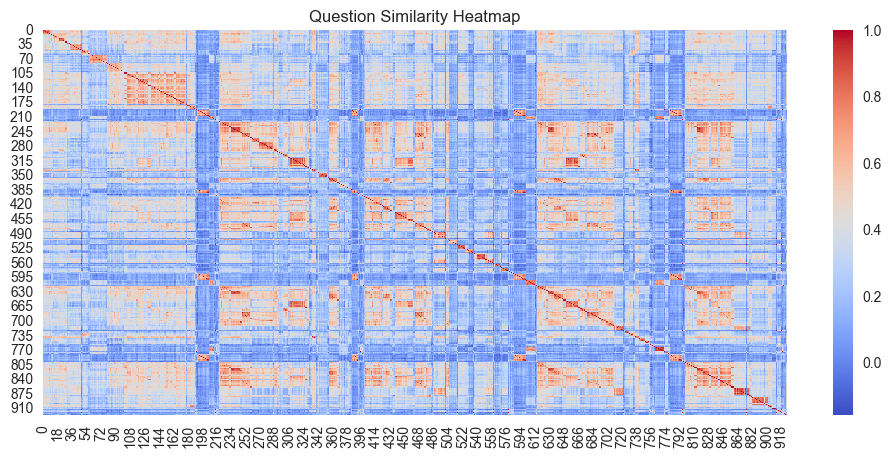

 Similarity Matrix Computed & Saved!


In [124]:

# Find similar questions by computing Cosine Similarity.
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns


# Convert embeddings to numpy array
question_embeddings = np.array(survey_questions_df["sbert_embedding"].tolist())

# Compute cosine similarity matrix
similarity_matrix = cosine_similarity(question_embeddings)

# plot correlation heatmap
plt.figure(figsize=(12, 5))
sns.heatmap(similarity_matrix, cmap="coolwarm", annot=False)
plt.title("Question Similarity Heatmap")
plt.show()


# Save similarity matrix
np.save("/Users/tiruskimani/MSDATA/capstone/KSU/new/similarity_matrix.npy", similarity_matrix)

print(" Similarity Matrix Computed & Saved!")


In [126]:
display(similarity_matrix)

array([[ 1.        ,  0.89268252,  0.8347344 , ...,  0.14576696,
        -0.02100851,  0.49046056],
       [ 0.89268252,  1.        ,  0.81194473, ...,  0.18189246,
         0.01656735,  0.3852785 ],
       [ 0.8347344 ,  0.81194473,  1.        , ...,  0.15208148,
         0.09942533,  0.42137667],
       ...,
       [ 0.14576696,  0.18189246,  0.15208148, ...,  1.        ,
         0.28955462,  0.06085162],
       [-0.02100851,  0.01656735,  0.09942533, ...,  0.28955462,
         1.        ,  0.03431009],
       [ 0.49046056,  0.3852785 ,  0.42137667, ...,  0.06085162,
         0.03431009,  1.        ]])

##  Cluster Questions Using Hierarchical Clustering

In [127]:
# Convert to DataFrame
df_questions = pd.DataFrame(survey_questions_df, columns=["cleaned_question"])

# Vectorize the text using TF-IDF
vectorizer = TfidfVectorizer(stop_words="english")
question_embeddings = vectorizer.fit_transform(df_questions["cleaned_question"])
question_embeddings = question_embeddings.toarray()

print("Vector dimensions",question_embeddings.shape)

Vector dimensions (925, 1075)


In [ ]:
# question_embeddings = np.array(survey_questions_df["sbert_embedding"].tolist())
# print("Vector dimensions",question_embeddings.shape)

### Find Best Optimal K

In [133]:
N = len(cleaned_survey_questions)  
# max_k = use the square root of total questions
#max_k =  math.ceil(math.sqrt(N)) + 10
# max_k = use 10% of total questions
max_k = int(0.1 * N)

##### Find Best Optimal K based on WCSS(Within-Cluster Sum of Squares/Total Sum of Squares)  & silhouette score,  with capped max_k(sqrt) 

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


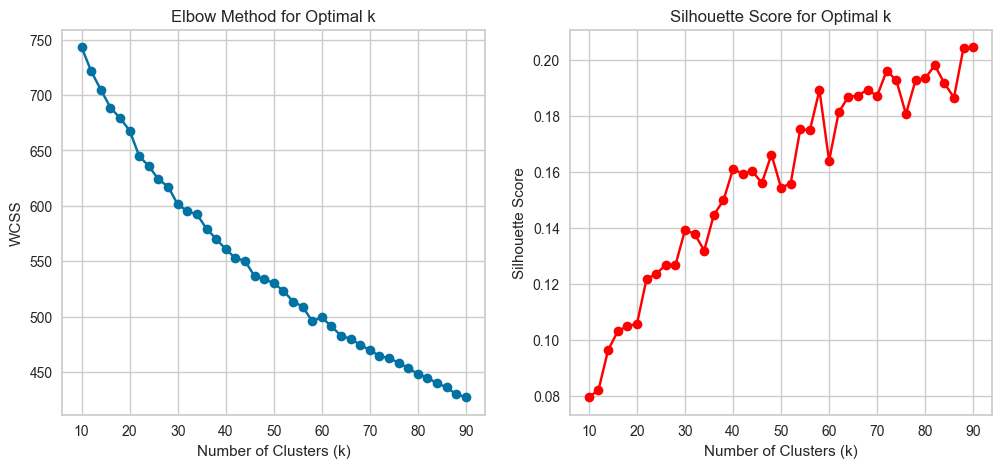

Max k: 92
Optimal Number of Clusters: 90


In [135]:
### Step 1: Find Optimal `k` Using the Elbow Method- Identifies the point where adding more clusters doesn't significantly reduce the intra-cluster variance.

wcss = []  # Within-Cluster Sum of Squares
sil_scores = []


K_range = range(10, max_k ,2)  # Avoid k > num_questions, Testing different k values : starting at 10 clusters, step up by 2 for compute efficiency
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans.fit(question_embeddings)
    
    wcss.append(kmeans.inertia_)  # Inertia (WCSS)
    
    # Compute silhouette score- Silhouette Score – Measures how well each point fits within its assigned cluster
    sil_score = silhouette_score(question_embeddings, kmeans.labels_)
    sil_scores.append(sil_score)

# Plot Elbow Method
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K_range, wcss, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal k")

# Plot Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(K_range, sil_scores, marker="o", color="red")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Optimal k")

plt.show()

optimal_k = K_range[np.argmax(sil_scores)]  # Pick the best `k` based on silhouette score

print(f"Max k: {max_k}")
print(f"Optimal Number of Clusters: {optimal_k}")

##### Find Best Optimal K based on distortions (average sum of squared distances) & silhouette score,  with capped max_k (sqrt)

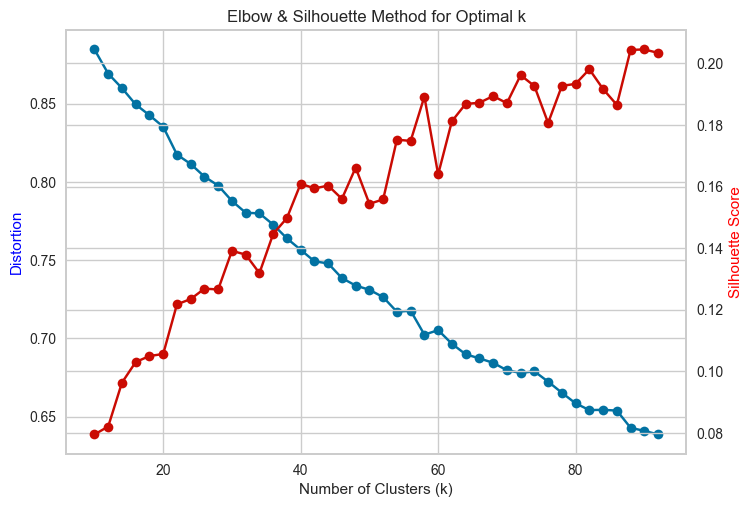

Max k: 92
Optimal K: 90


In [136]:



### Find Optimal K Using Elbow Method**
def find_optimal_k(embeddings, max_k):
    distortions = []  # measure how spread out the clusters are : lower distortion means clusters are compact
    silhouette_scores = []
    K_range = range(10, max_k + 1, 2)  # Testing different k values : starting at 10 clusters, step up by 2 for compute efficiency

    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=0, n_init=10) # n_init: run the kmeans algo n times with different centroids to impove chances of finding a good cluster
        kmeans.fit(embeddings)
        distortions.append(sum(np.min(cdist(embeddings, kmeans.cluster_centers_, 'euclidean'), axis=1)) / embeddings.shape[0])
        silhouette_scores.append(silhouette_score(embeddings, kmeans.labels_))
    
    
    optimal_k = K_range[np.argmax(silhouette_scores)]  # Pick the best `k` based on silhouette score
    # Plot Elbow & Silhouette Scores
    fig, ax1 = plt.subplots()

    ax2 = ax1.twinx()
    ax1.plot(K_range, distortions, 'bo-', label="Distortion (Elbow)")
    ax2.plot(K_range, silhouette_scores, 'ro-', label="Silhouette Score")

    ax1.set_xlabel("Number of Clusters (k)")
    ax1.set_ylabel("Distortion", color="blue")
    ax2.set_ylabel("Silhouette Score", color="red")
    plt.title("Elbow & Silhouette Method for Optimal k")
    plt.show()
    return optimal_k




optimal_k = find_optimal_k(question_embeddings, max_k) # max_k : test upto n clusters to ensure we cover a broad range and dont miss a potential optimal number

print(f"Max k: {max_k}")
print(f"Optimal K: {optimal_k}")

#### Charts interpretation

Based on the chart, the silhouette score keeps rising and distortion keeps falling as k increases. 
Although we don’t see a single sharp ‘elbow,’ the silhouette appears to reach a high value near k=45–60. At that point, distortion is already quite low, and adding more clusters beyond 50 doesn’t dramatically increase the silhouette score. Therefore, k ≈ 45–60 is likely a good balance between compact, well-separated clusters and practical manageability.

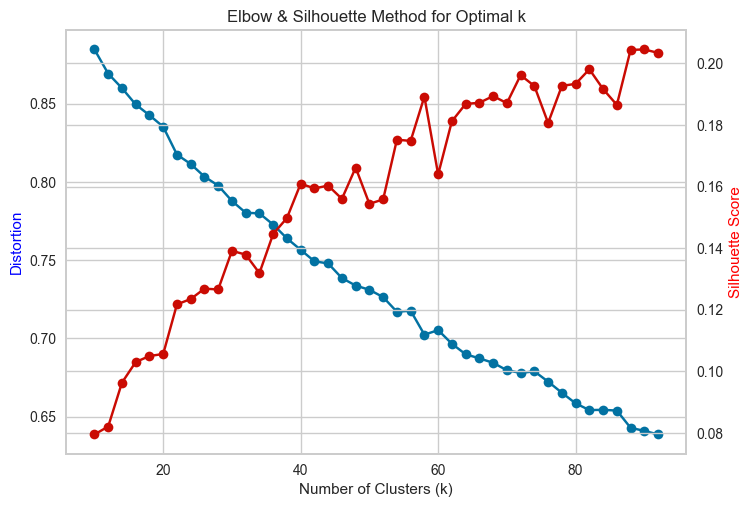

Max k: 92
Optimal k (via knee locator): 54


In [137]:
from kneed import KneeLocator

def find_optimal_k_with_knee(embeddings, max_k):
    distortions = []  # To store average distortion values for each k
    silhouette_scores = []
    K_range = list(range(10, max_k + 1, 2))  # Testing different k values

    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
        kmeans.fit(embeddings)
        # Calculate average distortion (average minimum distance to centroids)
        distortion = sum(np.min(cdist(embeddings, kmeans.cluster_centers_, 'euclidean'), axis=1)) / embeddings.shape[0]
        distortions.append(distortion)
        silhouette_scores.append(silhouette_score(embeddings, kmeans.labels_))

    # Use KneeLocator to identify the "elbow" in the distortion curve
    # Since distortion is convex and decreasing, set curve='convex' and direction='decreasing'
    kneedle = KneeLocator(K_range, distortions, curve='convex', direction='decreasing')
    optimal_k = kneedle.knee

    # Optional: Plot the results to visually verify the knee
    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()
    ax1.plot(K_range, distortions, 'bo-', label="Distortion (Elbow)")
    ax2.plot(K_range, silhouette_scores, 'ro-', label="Silhouette Score")
    ax1.set_xlabel("Number of Clusters (k)")
    ax1.set_ylabel("Distortion", color="blue")
    ax2.set_ylabel("Silhouette Score", color="red")
    plt.title("Elbow & Silhouette Method for Optimal k")
    plt.show()

    return optimal_k

optimal_k_knee = find_optimal_k_with_knee(question_embeddings, max_k)
print(f"Max k: {max_k}")
print(f"Optimal k (via knee locator): {optimal_k_knee}")


In [ ]:
### Automatic Optimal K calculation based on yellowbrick visualizer 
# ### Find Optimal K Using Elbow Method
# def find_optimal_k(embeddings, max_k):
#     distortions = []  # measure how spread out the clusters are : lower distortion means clusters are compact
#     silhouette_scores = []
#     K_range = range(10, max_k + 1, 2)  # Testing different k values : starting at 10 clusters, step up by 2 for compute efficiency

#     for k in K_range:
#         kmeans = KMeans(n_clusters=k, random_state=0, n_init=10) # n_init: run the kmeans algo n times with different centroids to impove chances of finding a good cluster
#         kmeans.fit(embeddings)
#         # calculate distortions
#         distortions.append(sum(np.min(cdist(embeddings, kmeans.cluster_centers_, 'euclidean'), axis=1)) / embeddings.shape[0])
#         # calculate silhouette_scores
#         silhouette_scores.append(silhouette_score(embeddings, kmeans.labels_))
#         # calculate elbow value using visualizer 
#         visualizer = KElbowVisualizer(kmeans, k=(2, max_k))
#         visualizer.fit(question_embeddings) 
#         elbow_viz_k= visualizer.elbow_value_
    
#     optimal_k_silhoutte = K_range[np.argmax(silhouette_scores)]  # Pick the best `k` based on silhouette score
#     print("Optimal k based on silhouette score:", optimal_k_silhoutte)
#     optimal_k_viz = elbow_viz_k # Pick the best `k` based on yellowbrick visualizer, elbow method
#     print("Optimal k based on the elbow method:", optimal_k_viz)
    
#     # Plot Elbow & Silhouette Scores
#     fig, ax1 = plt.subplots()

#     ax2 = ax1.twinx()
#     ax1.plot(K_range, distortions, 'bo-', label="Distortion (Elbow)")
#     ax2.plot(K_range, silhouette_scores, 'ro-', label="Silhouette Score")

#     ax1.set_xlabel("Number of Clusters (k)")
#     ax1.set_ylabel("Distortion", color="blue")
#     ax2.set_ylabel("Silhouette Score", color="red")
#     plt.title("Elbow & Silhouette Method for Optimal k")
#     plt.show()
    
#     return optimal_k_silhoutte


# # Set an initial range based on your heuristic:
# N = len(cleaned_survey_questions)
# # max_k = maximum cluster considered, use a fraction of the total, we use the square root of total questions
# max_k = math.ceil(math.sqrt(N))

# optimal_k = find_optimal_k(question_embeddings, max_k) # max_k : test upto n clusters to ensure we cover a broad range and dont miss a potential optimal number

# print(f"Max k: {max_k}")
# print(f"Optimal K: {optimal_k}")

In [141]:
optimal_k_knee

54

In [143]:
# we set optimal k at elbow
optimal_k_visual = 55
optimal_k_knee_predicted = optimal_k_knee

#### Feature Separation to enhance KMeans : Dimensionality reduction

##### PCA to Improve Feature Separation Before Clustering - To reduce high demensional TF-IDF vectors into lower-dimensional space while retaining most of variance -keep important info.

##### Cumulative Explained Variance Plot


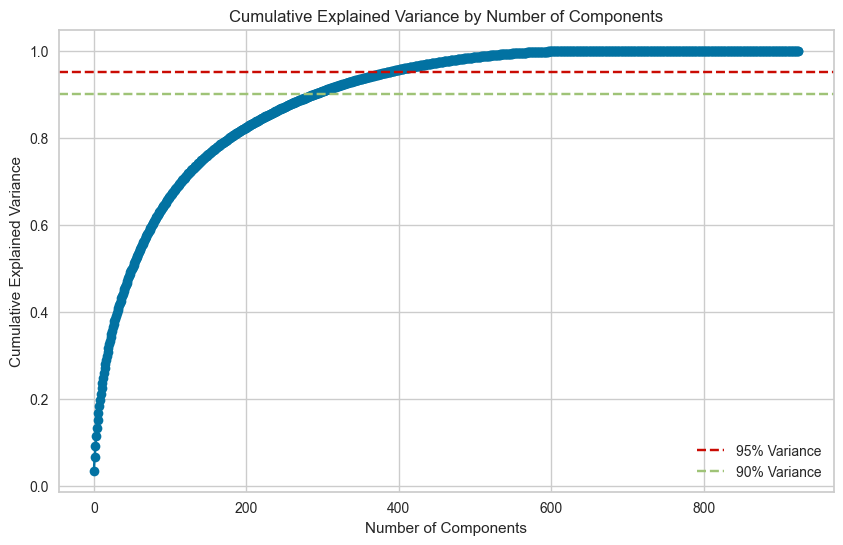

In [145]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# Fit PCA without reducing dimensions first
pca_full = PCA()
pca_full.fit(question_embeddings)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(cumulative_variance, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.axhline(y=0.90, color='g', linestyle='--', label='90% Variance')
plt.legend()
plt.title("Cumulative Explained Variance by Number of Components")
plt.show()

#### Calculate the Knee/elbow value, to detect suitable n_components while retaining variance

In [147]:
from kneed import KneeLocator

# Assuming cumulative_variance and component indices are computed as above:
x = np.arange(1, len(cumulative_variance) + 1)
kneedle = KneeLocator(x, cumulative_variance, curve='concave', direction='increasing')
optimal_components = kneedle.knee
print("Optimal number of components:", optimal_components)


Optimal number of components: 201


In [149]:
n_components = optimal_components
n_components_fixed = 20

In [151]:
# Keep enough components to explain 95% of the variance
pca = PCA(n_components) # 95% - Reduce dimensions from original to reduce noise/keep important only/remove redundant features
embeddings_pca = pca.fit_transform(question_embeddings)
print("Number of components chosen to retain most of variance:", pca.n_components_)

Number of components chosen to retain most of variance: 201


## Clustering

### 1. KMeans Clustering

##### Perform kmeans clustering on the PCA transformations and Optimal K

In [152]:
# Run K-Means with Optimal k
## optimal_k - Choosen based on visual analysis from the Elbow & Silhouette score
## optimal_k_knee_predicted - Automatically chosen using kneeLocator on distortions
best_k = optimal_k_knee_predicted  # optimal_k 
# best_k = 100
kmeans = KMeans(n_clusters=best_k, random_state=0, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings_pca) # partition the question data into meaningful groups (clusters)

In [155]:
best_k

54

##### Visualizing Clusters with t-SNE (t-distributed Stochastic Neighbour Embedding)

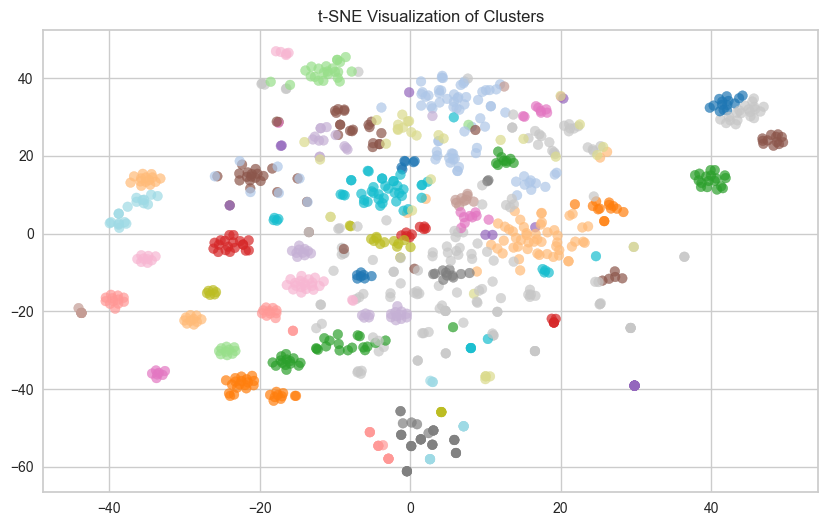

In [157]:
# Technique to visualize high-dimensional data by projecting it into a 2D space
tsne = TSNE(n_components=2, perplexity=30, random_state=0) # n_components: 2  dimensions for easy visualization, perplexity - balances local and global aspects of the data 
tsne_embeddings = tsne.fit_transform(embeddings_pca)

plt.figure(figsize=(10, 6))
plt.scatter(tsne_embeddings[:, 0], tsne_embeddings[:, 1], c=cluster_labels, cmap="tab20", alpha=0.7)
plt.title("t-SNE Visualization of Clusters")
plt.show()



#### Attach KMeans PCA clusters to Questions

In [161]:
# Attach Cluster Labels to Questions
survey_questions_df["kmeans_pca_cluster"] = cluster_labels

print(f"Best Number of Clusters: {best_k}")
print("Clustered questions saved!")

Best Number of Clusters: 54
Clustered questions saved!


#### 2. Agglomerative/Hierachical Clustering

##### Each question was assigned lda_topic and bert_topic, we find the average to compute a combined_cluster balancing btn LDA and BERTtopic

In [163]:
best_k

54

In [165]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering

# Compute average topic per question
survey_questions_df["combined_topic"] = (
    0.5 * survey_questions_df["lda_topic"] + 0.5 * survey_questions_df["bertopic_topic"]
)

# Cluster 
num_clusters = best_k
clustering_model = AgglomerativeClustering(n_clusters=num_clusters)
# Fit to predict cluster labels
survey_questions_df["combined_cluster"] = clustering_model.fit_predict(survey_questions_df[["combined_topic"]])

In [167]:
survey_questions_df.head()

,original_question,cleaned_question,sbert_embedding,lda_topic,bertopic_topic,kmeans_pca_cluster,combined_topic,combined_cluster
0,Q1[01][F].Perceptions of the City. Please rate...,please rate following items circling correspon...,"[0.06747598201036453, 0.03872975334525108, -0....",5,14,53,9.5,21
1,Q1[02][F].Perceptions of the City. Please rate...,please rate following items circling correspon...,"[0.07277697324752808, -0.015492288395762444, -...",5,14,53,9.5,21
2,Q1[03][F].Perceptions of the City. Please rate...,please rate following items circling correspon...,"[0.011186150833964348, 0.033436648547649384, -...",5,14,53,9.5,21
3,Q1[04][F].Perceptions of the City. Please rate...,please rate following items circling correspon...,"[0.06636805087327957, 0.04292367771267891, -0....",5,14,53,9.5,21
4,Q1[05][F].Perceptions of the City. Please rate...,please rate following items circling correspon...,"[0.06536620855331421, 0.06463699787855148, -0....",5,14,53,9.5,21


##### Visualize Hierachical Clustering Dendrogram

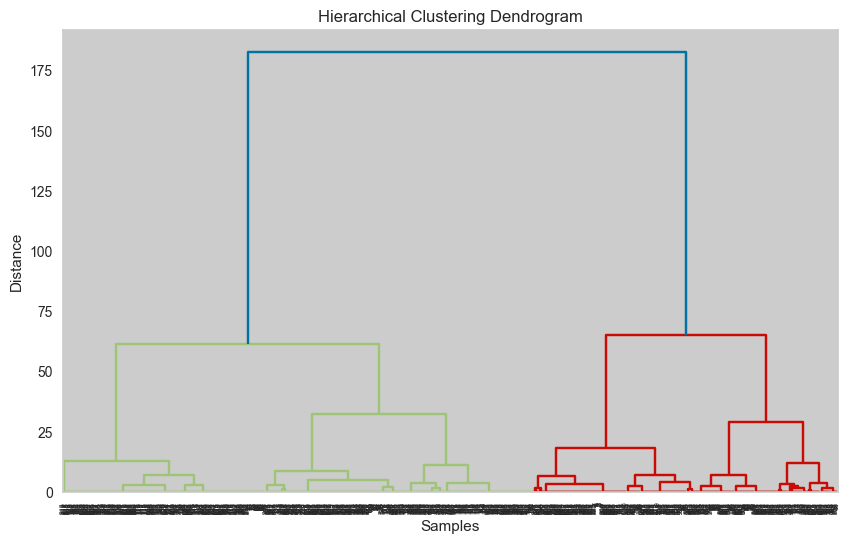

In [169]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage

# Convert to NumPy array for linkage
X = survey_questions_df[["combined_topic"]].values

# Create linkage matrix using Ward’s method (same as default in AgglomerativeClustering)
Z = linkage(X, method='ward')

# Plot the dendrogram
plt.figure(figsize=(10, 6))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()


#### Visualizing Hierachical Clustering Distribution Plot (KDE)

In [ ]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# plt.figure(figsize=(20, 6))

# for cluster_id in survey_questions_df["combined_cluster"].unique():
#     # Extract the 'combined_topic' values for the current cluster
#     data = survey_questions_df.loc[
#         survey_questions_df["combined_cluster"] == cluster_id, 
#         "combined_topic"
#     ]
    
#     # Plot only if we have at least 2 data points
#     if len(data) > 1:
#         sns.kdeplot(data, label=f"Cluster {cluster_id}", shade=True)
#     else:
#         # Optional fallback for a single data point:
#         # Plot a small dot or skip entirely
#         plt.scatter(data, [0]*len(data), label=f"Cluster {cluster_id}", marker='x')

# plt.title("Distribution of Combined Topic per Cluster")
# plt.xlabel("combined_topic")
# plt.legend()
# plt.show()


In [171]:
display(survey_questions_df["combined_cluster"].value_counts())


combined_cluster
16    89
23    76
15    71
21    68
0     51
11    50
8     50
33    33
13    29
9     29
1     25
27    24
25    24
18    24
6     22
2     22
10    21
4     20
5     19
28    17
29    17
31    14
32    13
22    13
14    12
12    11
30    11
7      9
35     8
3      8
19     7
24     6
17     5
34     5
26     2
20     2
37     1
44     1
49     1
50     1
45     1
40     1
41     1
42     1
43     1
52     1
46     1
51     1
53     1
47     1
48     1
38     1
36     1
39     1
Name: count, dtype: int64

In [ ]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 6))

# for cluster_id in survey_questions_df["combined_cluster"].unique():
#     # Extract data for the current cluster
#     data = survey_questions_df.loc[
#         survey_questions_df["combined_cluster"] == cluster_id, 
#         "combined_topic"
#     ]
    
#     # Plot only if we have at least 2 points
#     if len(data) > 1:
#         sns.kdeplot(data, label=f"Cluster {cluster_id}", shade=True)
#     else:
#         Optionally, mark single data points or skip them
#         # Example: scatter a small marker
#         plt.scatter(data, [0]*len(data), label=f"Cluster {cluster_id}", marker='x')

# plt.title("Distribution of Combined Topic per Cluster")
# plt.xlabel("combined_topic")
# plt.legend()
# plt.show()


In [ ]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 6))
# for cluster_id in survey_questions_df["combined_cluster"].unique():
#     sns.kdeplot(
#         survey_questions_df.loc[survey_questions_df["combined_cluster"] == cluster_id, "combined_topic"],
#         label=f"Cluster {cluster_id}",
#         shade=True
#     )
# plt.title("Distribution of Combined Topic per Cluster")
# plt.xlabel("combined_topic")
# plt.legend()
# plt.show()

In [ ]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# plt.figure(figsize=(20, 6))
# for cluster_id in survey_questions_df["combined_cluster"].unique():
#     sns.kdeplot(
#         survey_questions_df.loc[survey_questions_df["combined_cluster"] == cluster_id, "combined_topic"],
#         label=f"Cluster {cluster_id}",
#         shade=True
#     )
# plt.title("Distribution of Combined Topic per Cluster")
# plt.xlabel("combined_topic")
# plt.legend()
# plt.show()



#### 3. Flattening hierachical clustering (cutting dendogram)

##### performing hierarchical clustering with a linkage matrix and then cutting it into flat clusters allows us to leverage both the detailed hierarchical relationships between data points and the practical need for a specific number of clusters. 

In [173]:
from scipy.cluster.hierarchy import linkage,fcluster

# Perform hierarchical clustering
linkage_matrix = linkage(question_embeddings, method="ward")

num_clusters = best_k
clusters = fcluster(linkage_matrix, num_clusters, criterion="maxclust")

# Assign cluster labels to questions
survey_questions_df["fcluster"] = clusters

# Save clustered questions
survey_questions_df.to_csv("/Users/tiruskimani/MSDATA/capstone/KSU/new/clustered_questions.csv", index=False)

print(f"Questions clustered into {num_clusters} groups!")

Questions clustered into 54 groups!


#### Extract the Most Representative Question Per Cluster

In [ ]:
display(survey_questions_df)

In [175]:
def clean_original_question(question):
    if pd.isna(question):  
        return question  # Return as-is if it's NaN (missing)
    
    # Replace city names with placeholder
    for city in city_names:
        question = re.sub(rf"\b{city}\b", "[city name]", question, flags=re.IGNORECASE)
        
   # Remove patterns like 'Q16[01][K].', 'Q6[11][F].', 'Q20[N].', 'Q25[L].', 'Q19a[L].'
    question = re.sub(r'Q\d+[a-zA-Z]*\[\w+\]\.', '', question) 
    question = re.sub(r'^Q\d+[a-zA-Z]*\[\d+\]\[\w+\]\.', '', question) 
    # Remove the number inside '[number.' but keep the '[' and '.'
    question = re.sub(r'\[(\d+)\.', '[.', question)  # Converts '[11.' → '[.'
    
    # Remove 'Q16x4[T].', 'Q21x5[S].', 'Q23x3[S].' patterns
    question = re.sub(r'Q\d+x\d+\[\w+\]\.', '', question)
    
    return question

survey_questions_df = pd.DataFrame(survey_questions_df)

# Apply function to replace city names in each row
survey_questions_df["cleaned_original_question"] = survey_questions_df["original_question"].apply(clean_original_question)

In [177]:

display(survey_questions_df["cleaned_original_question"].sample(50))

441    Please rate your satisfaction with each of the...
233    Which THREE of the major categories of city se...
867    Please CHECK ALL of the sources of information...
853    Maintenance. Please rate your satisfaction wit...
587    Which of the following best describes your rac...
236    Please rate your satisfaction with each of the...
117    Which TWO of the public safety services listed...
53     Perceptions of Safety. Please indicate how saf...
127    Parks and Recreation. Please rate the City's p...
106    Public Safety Services. Please rate the City's...
519    Please indicate how the City of [city name] co...
98     For the items you selected, how would you rate...
240    Please rate your satisfaction with each of the...
638    Please rate your satisfaction with each of the...
248    Please rate your satisfaction with each of the...
708    Please rate your satisfaction with each of the...
905    Please rate your level of agreement with each ...
656    Please rate your satisfa

# Generate Generic Survey Database based clusters

##### 1. Generate Survey Using KMeans PCA clusters and highest average similarity 

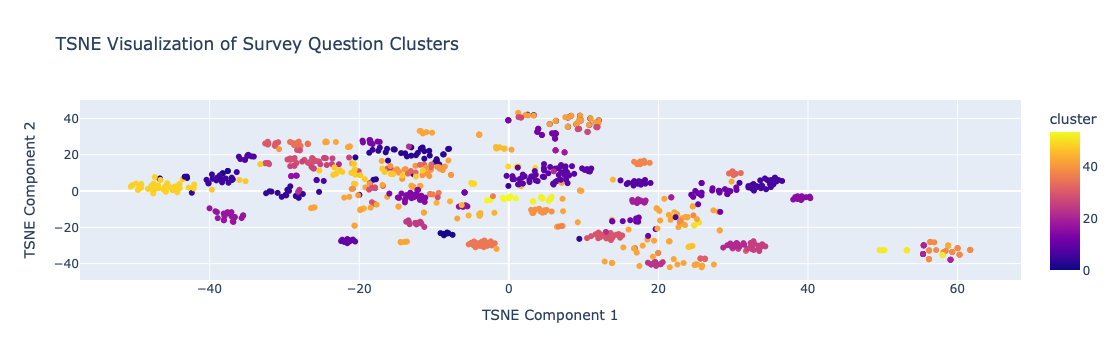

In [179]:
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.manifold import TSNE

# Assuming survey_questions_df contains:
# "sbert_embedding": a list column with SBERT embeddings,
# "kmeans_cluster": the cluster label for each question,
# "cleaned_question": the processed question text.

# Convert the list of embeddings to a NumPy array.
embeddings = np.array(survey_questions_df["sbert_embedding"].tolist())

# Use TSNE to reduce the dimensionality to 2 dimensions.
# - n_components=2: We want a 2D representation.
# - perplexity=30: A common value balancing local and global structure.
# - random_state=42: For reproducibility.
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(embeddings)

# Create a DataFrame for plotting.
plot_df = pd.DataFrame(tsne_results, columns=["tsne1", "tsne2"])
plot_df["cluster"] = survey_questions_df["kmeans_pca_cluster"].values
plot_df["question"] = survey_questions_df["cleaned_question"].values

# Create an interactive scatter plot with Plotly.
fig = px.scatter(
    plot_df, 
    x="tsne1", 
    y="tsne2", 
    color="cluster", 
    hover_data=["question"],
    title="TSNE Visualization of Survey Question Clusters",
    labels={"tsne1": "TSNE Component 1", "tsne2": "TSNE Component 2"}
)

fig.show()


In [181]:
# Select the most central question in each cluster.
# Select the most representative question per cluster (highest avg similarity)
def get_representative_question(cluster_id):
    cluster_questions = survey_questions_df[survey_questions_df["kmeans_pca_cluster"] == cluster_id]
    
    if cluster_questions.empty:
        print("Missing Cluster_question",len(cluster_questions))
        return {
            'generic_question': None,
            'original_question': None
        }
    
    
 
    cluster_embeddings = np.array(cluster_questions["sbert_embedding"].tolist())
    
    # Compute intra-cluster similarity
    cluster_sim_matrix = cosine_similarity(cluster_embeddings)
    
    # Select question with highest avg similarity within its cluster
    avg_similarities = cluster_sim_matrix.mean(axis=1)
    best_idx = avg_similarities.argmax()
    
    cluster_questions.iloc[best_idx]["cleaned_original_question"]
    
    return {
        'generic_question':cluster_questions.iloc[best_idx]["cleaned_original_question"],
        'original_question':cluster_questions.iloc[best_idx]["original_question"]
    }
        



# Generate generic survey question list
kmeans_generic_questions = [
    {"cluster": i, "generic_question": get_representative_question(i)['generic_question'],'original_question':get_representative_question(i)['original_question']}
    for i in range(1, num_clusters)
]
display(kmeans_generic_questions)

[{'cluster': 1,
  'generic_question': 'The City is aware of a shortage of housing nationwide and locally. Different housing types not already offered in [city name] will help meet the needs of future generations in our community. Do you support the City facilitating more housing in [city name] through... [Fourplexes]',
  'original_question': 'Q19[05][M].The City is aware of a shortage of housing nationwide and locally. Different housing types not already offered in Overland Park will help meet the needs of future generations in our community. Do you support the City facilitating more housing in Overland Park through... [Fourplexes]'},
 {'cluster': 2,
  'generic_question': 'Please rate your satisfaction with each of the park services listed. [. Number of walking and biking trails in the City]',
  'original_question': 'Q10[06][F].Please rate your satisfaction with each of the park services listed. [06. Number of walking and biking trails in the City]'},
 {'cluster': 3,
  'generic_questio

##### 2. Generic Survey Using Combined Topic Clusters (lda_topic,bert_topic) against agglomerative/Hierachical clustering

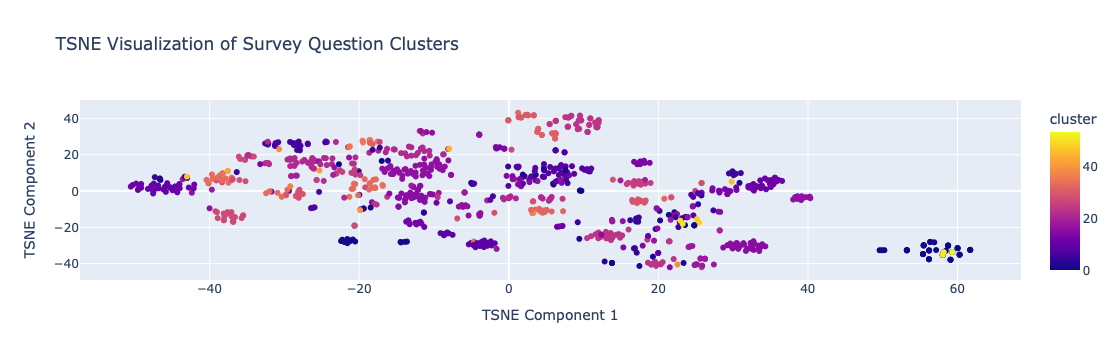

In [183]:
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.manifold import TSNE

# Assuming survey_questions_df contains:
# "sbert_embedding": a list column with SBERT embeddings,
# "kmeans_cluster": the cluster label for each question,
# "cleaned_question": the processed question text.

# Convert the list of embeddings to a NumPy array.
embeddings = np.array(survey_questions_df["sbert_embedding"].tolist())

# Use TSNE to reduce the dimensionality to 2 dimensions.
# - n_components=2: We want a 2D representation.
# - perplexity=30: A common value balancing local and global structure.
# - random_state=42: For reproducibility.
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(embeddings)

# Create a DataFrame for plotting.
plot_df = pd.DataFrame(tsne_results, columns=["tsne1", "tsne2"])
plot_df["cluster"] = survey_questions_df["combined_cluster"].values
plot_df["question"] = survey_questions_df["cleaned_question"].values

# Create an interactive scatter plot with Plotly.
fig = px.scatter(
    plot_df, 
    x="tsne1", 
    y="tsne2", 
    color="cluster", 
    hover_data=["question"],
    title="TSNE Visualization of Survey Question Clusters",
    labels={"tsne1": "TSNE Component 1", "tsne2": "TSNE Component 2"}
)

fig.show()


In [ ]:
def get_representative_question(cluster_id):
    cluster_questions = survey_questions_df[survey_questions_df["combined_cluster"] == cluster_id]
    
    if cluster_questions.empty:
        print("Missing Cluster_question",len(cluster_questions))
        return {
            'generic_question': None,
            'original_question': None
        }
    cluster_embeddings = np.array(cluster_questions["sbert_embedding"].tolist())
    
    # Compute intra-cluster similarity
    cluster_sim_matrix = cosine_similarity(cluster_embeddings)
    
    # Select question with highest avg similarity within its cluster
    avg_similarities = cluster_sim_matrix.mean(axis=1)
    best_idx = avg_similarities.argmax()
    
    cluster_questions.iloc[best_idx]["cleaned_original_question"]
    
    return {
        'generic_question':cluster_questions.iloc[best_idx]["cleaned_original_question"],
        'original_question':cluster_questions.iloc[best_idx]["original_question"]
    }
        



# Generate generic survey question list
combined_topic_generic_questions = [
    {"cluster": i, "generic_question": get_representative_question(i)['generic_question'],'original_question':get_representative_question(i)['original_question']}
    for i in range(1, num_clusters)
]
display(combined_topic_generic_questions)

##### 3. Generate Survey Using Fcluster clusters and highest average similarity 

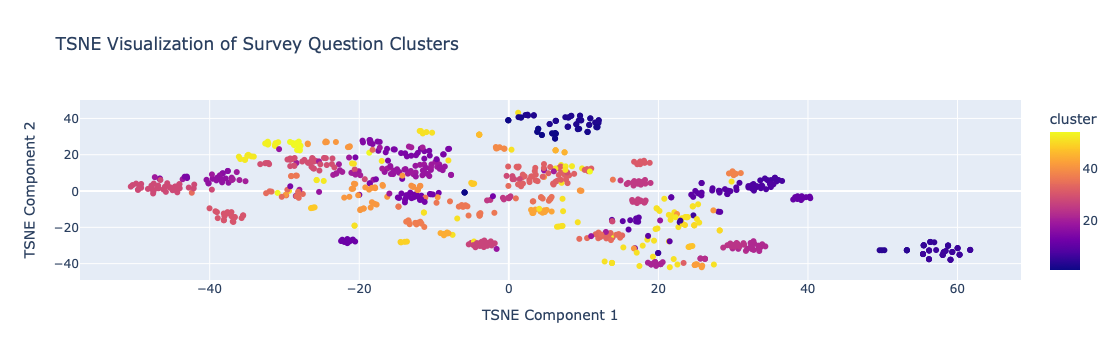

In [185]:
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.manifold import TSNE

# Assuming survey_questions_df contains:
# "sbert_embedding": a list column with SBERT embeddings,
# "kmeans_cluster": the cluster label for each question,
# "cleaned_question": the processed question text.

# Convert the list of embeddings to a NumPy array.
embeddings = np.array(survey_questions_df["sbert_embedding"].tolist())

# Use TSNE to reduce the dimensionality to 2 dimensions.
# - n_components=2: We want a 2D representation.
# - perplexity=30: A common value balancing local and global structure.
# - random_state=42: For reproducibility.
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(embeddings)

# Create a DataFrame for plotting.
plot_df = pd.DataFrame(tsne_results, columns=["tsne1", "tsne2"])
plot_df["cluster"] = survey_questions_df["fcluster"].values
plot_df["question"] = survey_questions_df["cleaned_original_question"].values

# Create an interactive scatter plot with Plotly.
fig = px.scatter(
    plot_df, 
    x="tsne1", 
    y="tsne2", 
    color="cluster", 
    hover_data=["question"],
    title="TSNE Visualization of Survey Question Clusters",
    labels={"tsne1": "TSNE Component 1", "tsne2": "TSNE Component 2"}
)

fig.show()


In [187]:
# Select the most central question in each cluster.
# Select the most representative question per cluster (highest avg similarity)
def get_representative_question(cluster_id):
    cluster_questions = survey_questions_df[survey_questions_df["fcluster"] == cluster_id]
     
    if cluster_questions.empty:
        print("Cluster_question",len(cluster_questions))
        return {
            'generic_question': None,
            'original_question': None
        }
    cluster_embeddings = np.array(cluster_questions["sbert_embedding"].tolist())
    
    # Compute intra-cluster similarity
    cluster_sim_matrix = cosine_similarity(cluster_embeddings)
    
    # Select question with highest avg similarity within its cluster
    avg_similarities = cluster_sim_matrix.mean(axis=1)
    best_idx = avg_similarities.argmax()
    
    cluster_questions.iloc[best_idx]["cleaned_original_question"]
    
    return {
        'generic_question':cluster_questions.iloc[best_idx]["cleaned_original_question"],
        'original_question':cluster_questions.iloc[best_idx]["original_question"]
    }
        



# Generate generic survey question list
fcluster_generic_questions = [
    {"cluster": i, "generic_question": get_representative_question(i)['generic_question'],'original_question':get_representative_question(i)['original_question']}
    for i in range(1, num_clusters + 1)
]
display(fcluster_generic_questions)

[{'cluster': 1,
  'generic_question': "Which FOUR of the services listed above do you think should be the City's top priorities? [2nd:]",
  'original_question': "Q8[02][F].Which FOUR of the services listed above do you think should be the City's top priorities? [2nd:]"},
 {'cluster': 2,
  'generic_question': 'Which THREE of the City services listed in Question 1 do you think are most important for the City to emphasize over the next TWO years? [1st:]',
  'original_question': 'Q2[01][F].Which THREE of the City services listed in Question 1 do you think are most important for the City to emphasize over the next TWO years? [1st:]'},
 {'cluster': 3,
  'generic_question': 'Which THREE of the items listed in Question 1 do you think should receive the MOST EMPHASIS from City leaders over the next TWO years? [2nd:]',
  'original_question': 'Q2[02][F].Which THREE of the items listed in Question 1 do you think should receive the MOST EMPHASIS from City leaders over the next TWO years? [2nd:]'},


### Choose best generic question cluster to apply

In [195]:
generic_questions = fcluster_generic_questions

In [197]:
def add_answer_options(df, generic_questions):
    max_options = 10  # Maximum number of answer options to store

    for i, question in enumerate(generic_questions):
        if 'original_question' in question:
            original_question_text = question['original_question']
            
            # Ensure the column exists in df
            if original_question_text in df.columns:
                # Get unique answer options
                answer_options = df[original_question_text].dropna().unique().tolist()
                
                print(f"Processing question: {original_question_text}")
                print("Answer options found:", len(answer_options))
                
                # Create a dictionary of answer option columns (up to max_options)
                option_columns = {f"option_{j+1}": (answer_options[j] if j < len(answer_options) else None) for j in range(max_options)}

                # Update the dictionary at the respective index
                generic_questions[i].update(option_columns)

add_answer_options(merged_df, generic_questions)

Processing question: Q8[02][F].Which FOUR of the services listed above do you think should be the City's top priorities? [2nd:]
Answer options found: 22
Processing question: Q2[01][F].Which THREE of the City services listed in Question 1 do you think are most important for the City to emphasize over the next TWO years? [1st:]
Answer options found: 13
Processing question: Q2[02][F].Which THREE of the items listed in Question 1 do you think should receive the MOST EMPHASIS from City leaders over the next TWO years? [2nd:]
Answer options found: 12
Processing question: Q26[06][M].Which of the following best describes your race/ethnicity? [Hispanic, Spanish, or Latino/a/x]
Answer options found: 3
Processing question: Q26[03][M].Which of the following best describes your race/ethnicity? [American Indian or Alaska Native]
Answer options found: 3
Processing question: Q26[99][M].Which of the following best describes your race/ethnicity? [Other]
Answer options found: 3
Processing question: Q15[1

In [199]:
generic_questions

[{'cluster': 1,
  'generic_question': "Which FOUR of the services listed above do you think should be the City's top priorities? [2nd:]",
  'original_question': "Q8[02][F].Which FOUR of the services listed above do you think should be the City's top priorities? [2nd:]",
  'option_1': 'nan:nan',
  'option_2': '9.0:09. Maintenance of infrastructure (e.g., city streets and sidewalks)',
  'option_3': '20.0:20. 311/Service request process (call to report problem)',
  'option_4': '11.0:11. Police services',
  'option_5': '3.0:03. Neighborhood code enforcement (e.g., high weeds, litter, blight)',
  'option_6': '1.0:01. Ambulance/emergency medical services',
  'option_7': '19.0:19. Social services (community centers, child care programs, homeless programs, senior programs)',
  'option_8': '6.0:06. Fire services',
  'option_9': '17.0:17. Dallas Love Field Airport',
  'option_10': '7.0:07. Solid waste services (e.g., garbage and recycling collection)'},
 {'cluster': 2,
  'generic_question': 'Whi

In [201]:
# Convert to DataFrame
generic_questions_df = pd.DataFrame(generic_questions)

display(generic_questions_df.sample(10))

,cluster,generic_question,original_question,option_1,option_2,option_3,option_4,option_5,option_6,option_7,option_8,option_9,option_10
0,1,Which FOUR of the services listed above do you...,Q8[02][F].Which FOUR of the services listed ab...,nan:nan,"9.0:09. Maintenance of infrastructure (e.g., c...",20.0:20. 311/Service request process (call to ...,11.0:11. Police services,"3.0:03. Neighborhood code enforcement (e.g., h...",1.0:01. Ambulance/emergency medical services,"19.0:19. Social services (community centers, c...",6.0:06. Fire services,17.0:17. Dallas Love Field Airport,"7.0:07. Solid waste services (e.g., garbage an..."
43,44,The City is aware of a shortage of housing nat...,Q19[05][M].The City is aware of a shortage of ...,nan:nan,Y:Yes,nan:No,None,None,None,None,None,None,None
20,21,"Please define ""Other.""","Q5x14[T].Please define ""Other.""",Affordable housing,The houseless community does not have access t...,Total lack of adequate public transportation,"Minor crime , code violations","Poor infrastructure. Incompetent, dishonest, i...",Abusive and inequitable property code enforcem...,Other concerns,Walkability.,"Elimate Section 8 housing, eliminate short ter...","Lack of safety, Lack of streets getting fixed,..."
38,39,Please CHECK ALL of the following items that w...,Q31[03][M].Please CHECK ALL of the following i...,nan:nan,nan:No,Y:Yes,None,None,None,None,None,None,None
41,42,What is your gender?,Q24[L].What is your gender?,nan:nan,1.0:Male,2.0:Female,3.0:Self-identified,None,None,None,None,None,None
37,38,How do you receive information about the city'...,Q34[06][M].How do you receive information abou...,nan:nan,nan:No,Y:Yes,None,None,None,None,None,None,None
2,3,Which THREE of the items listed in Question 1 ...,Q2[02][F].Which THREE of the items listed in Q...,nan:nan,4.0:04. Overall enforcement of City codes and ...,2.0:02. Overall quality of City parks and faci...,3.0:03. Overall maintenance of City streets,11.0:11. Overall quality of City's environment...,7.0:07. Overall traffic flow/congestion manage...,8.0:08. Overall traffic flow/congestion manage...,"1.0:01. Overall quality of police, fire, and e...",10.0:10. Overall quality of recreation programs,6.0:06. Overall effectiveness of City communic...
32,33,Major Categories of City Services. Please indi...,Q7[04][M].Major Categories of City Services. P...,nan:nan,Y:Yes,nan:No,None,None,None,None,None,None,None
26,27,When you think about the number and variety of...,Q13[14][F].When you think about the number and...,nan:nan,2.0:See about the same,1.0:See fewer,3.0:See more,9.0:Don't know,None,None,None,None,None
50,51,Living in [city name]. Which ONE of the follow...,Q29[L].Living in Johnston. Which ONE of the fo...,nan:nan,5.0:Close to family,3.0:Great quality of life,4.0:School system,8.0:Heard great things about the community,7.0:Like the small town feel,2.0:Close to work,1.0:Grew up in the region,9.0:Other,6.0:Affordable cost of living


#### Save final generic survey question set

In [203]:
# Save final generic survey question set
generic_questions_df.to_csv("/Users/tiruskimani/MSDATA/capstone/KSU/new/GenericSurvey.csv", index=False)

print(f"✅ Created {len(generic_questions_df)} Generic Survey Questions!")

✅ Created 54 Generic Survey Questions!


# Building the Similarity Algorithm

#### Develop Matching & Ranking Logic

##### Compute Similarity scores

In [205]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Load generic survey questions
generic_df = pd.read_csv("/Users/tiruskimani/MSDATA/capstone/KSU/new/GenericSurvey.csv")
cleaned_clustered_df = pd.read_csv("/Users/tiruskimani/MSDATA/capstone/KSU/new/clustered_questions.csv")

# Prepare data
historical_questions = cleaned_clustered_df["cleaned_question"].tolist()
generic_questions = generic_df["generic_question"].tolist()

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(stop_words="english")
tfidf_matrix = vectorizer.fit_transform(historical_questions + generic_questions)

# Separate matrices
historical_tfidf = tfidf_matrix[: len(historical_questions)]
generic_tfidf = tfidf_matrix[len(historical_questions) :]

# Compute similarity
similarity_scores = cosine_similarity(historical_tfidf, generic_tfidf)

# Convert to DataFrame
similarity_df = pd.DataFrame(
    similarity_scores, index=historical_questions, columns=generic_questions
)

# Save similarity matrix
similarity_df.to_csv("/Users/tiruskimani/MSDATA/capstone/KSU/new/similarity_scores.csv")

print("Similarity matrix saved!")


Similarity matrix saved!


### Confidence Ranking using the similarity scores

In [207]:
# Setting similarity threshold for ranks 80%- high & 70 % - medium
HIGH_CONFIDENCE_THRESHOLD = 0.7
MEDIUM_CONFIDENCE_THRESHOLD = 0.5


In [477]:
# Define thresholds
def classify_confidence(score):
    if score > HIGH_CONFIDENCE_THRESHOLD:
        return "High"
    elif score > MEDIUM_CONFIDENCE_THRESHOLD:
        return "Medium"
    else:
        return "Low"

matches = []
for hist_idx, hist_question in enumerate(historical_questions):
    best_match_idx = np.argmax(similarity_scores[hist_idx])
    best_match_score = similarity_scores[hist_idx][best_match_idx]
    best_match_question = generic_questions[best_match_idx]

    matches.append(
        {
            "historical_question": hist_question,
            "best_generic_question": best_match_question,
            "similarity_score": best_match_score,
            "confidence_level": classify_confidence(best_match_score),

        }
    )

# Convert to DataFrame
matches_df = pd.DataFrame(matches)
# add rank
matches_df["Rank"] = matches_df["similarity_score"].rank(method="dense", ascending=False).astype(int)

# Save results
matches_df.to_csv("/Users/tiruskimani/MSDATA/capstone/KSU/new/matched_questions.csv", index=False)

print("✅ Matches Classified & Saved!")
display(matches_df)


✅ Matches Classified & Saved!


,historical_question,best_generic_question,similarity_score,confidence_level,Rank
0,please rate following items circling correspon...,Please rate the City of [city name] with regar...,0.486411,Low,405
1,please rate following items circling correspon...,Please rate the City of [city name] with regar...,0.408580,Low,494
2,please rate following items circling correspon...,Please indicate the extent to which you think ...,0.384301,Low,528
3,please rate following items circling correspon...,Please indicate the extent to which you think ...,0.463036,Low,433
4,please rate following items circling correspon...,Please indicate the extent to which you think ...,0.424847,Low,473
...,...,...,...,...,...
920,gender none,What is your gender?,1.000000,High,3
921,please selfdescribe none,Which FOUR of the services listed above do you...,0.000000,Low,783
922,following best describes total annual househol...,Would you say your total annual household inco...,0.777862,High,107
923,highest level education attained none,Please rate your level of agreement with each ...,0.173998,Low,728


### Question Matching and Grouping

In [288]:
len(similarity_df)

925

In [374]:
high_confidence_questions = []
medium_confidence_questions = []
low_confidence_questions = []

In [471]:
import pandas as pd

# Initialize a list to store the ranking results.
ranking_results = []

# Iterate over each historical question (each row in the similarity_df)
for hist_question_id, row in similarity_df.iterrows():
    # Sort the generic questions by descending similarity score.
    sorted_matches = row.sort_values(ascending=False)

    
    # Enumerate through the sorted matches, starting rank at 1.
    for rank, (generic_question, similarity_score) in enumerate(sorted_matches.items(), start=1):
        ranking_results.append({
            "Historical_Question": hist_question_id,
            "Generic_Question": generic_question,
            "Similarity_Score": similarity_score,
            "Confidence_Level": classify_confidence(similarity_score),
            "Rank": rank
        })

# Convert the results into a DataFrame for easy viewing/analysis.
ranking_df = pd.DataFrame(ranking_results)

# Optionally, you can filter or group the results.
# For example, to view the top-ranked generic question for each historical question:
top_ranked = ranking_df[ranking_df["Rank"] == 1]
print(top_ranked)


                                     Historical_Question  \
0      please rate following items circling correspon...   
54     please rate following items circling correspon...   
108    please rate following items circling correspon...   
162    please rate following items circling correspon...   
216    please rate following items circling correspon...   
...                                                  ...   
49680                                        gender none   
49734                           please selfdescribe none   
49788  following best describes total annual househol...   
49842              highest level education attained none   
49896  suggestions city would like make please provid...   

                                        Generic_Question  Similarity_Score  \
0      Please rate the City of [city name] with regar...          0.486411   
54     Please rate the City of [city name] with regar...          0.408580   
108    Please indicate the extent to which yo

In [473]:
ranking_df.to_csv("/Users/tiruskimani/MSDATA/capstone/KSU/new/ranking.csv", index=False);

In [376]:
for idx, row in similarity_df.iterrows():
    max_similarity = row.max()
    best_match = row.idxmax()
    
    if max_similarity >= HIGH_CONFIDENCE_THRESHOLD:
        high_confidence_questions.append((idx, best_match, max_similarity, "High"))
    elif max_similarity >= MEDIUM_CONFIDENCE_THRESHOLD:
        medium_confidence_questions.append((idx, best_match, max_similarity, "Medium"))
    else:
        low_confidence_questions.append((idx,best_match , max_similarity, "Low"))

In [380]:
# Convert to DF
high_df = pd.DataFrame(high_confidence_questions, columns=["Historical Question", "Matched Template Question", "Similarity Score", "Confidence Level"])
medium_df = pd.DataFrame(medium_confidence_questions, columns=["Historical Question", "Matched Template Question", "Similarity Score", "Confidence Level"])
low_df = pd.DataFrame(low_confidence_questions, columns=["Historical Question", "Matched Template Question", "Similarity Score", "Confidence Level"])


high_df = high_df.sort_values(by="Similarity Score", ascending=False).reset_index(drop=True)
high_df["Rank"] = high_df["Similarity Score"].rank(method="dense", ascending=False).astype(int)

medium_df = medium_df.sort_values(by="Similarity Score", ascending=False).reset_index(drop=True)
medium_df["Rank"] = medium_df["Similarity Score"].rank(method="dense", ascending=False).astype(int)

low_df = low_df.sort_values(by="Similarity Score", ascending=False).reset_index(drop=True)
low_df["Rank"] = low_df["Similarity Score"].rank(method="dense", ascending=False).astype(int)


# save matches
high_df.to_csv(high_match_csv_path, index=False);
medium_df.to_csv(medium_match_csv_path, index=False);
low_df.to_csv(low_match_csv_path, index=False);




In [404]:
# Display results
print(f"High Confidence survey questions: {high_match_csv_path}");
display(high_df.sample(10));
print(f"Medium Confidence survey questions: {medium_match_csv_path}");
display(medium_df.sample(10));
print(f"Low Confidence survey questions: {low_match_csv_path}");
display(low_df.sample(10));

High Confidence survey questions: /Users/tiruskimani/MSDATA/capstone/KSU/new/high_matched_survey_questions.csv


,Historical Question,Matched Template Question,Similarity Score,Confidence Level,Rank
106,three city services listed question 1 think im...,Which THREE of the City services listed in Que...,0.848744,High,62
73,three public safety items listed question 4 th...,Which THREE of the items listed in Question 1 ...,0.903003,High,33
120,receive information citys budget money spent n...,How do you receive information about the city'...,0.835174,High,74
233,please check sources information use get infor...,Please CHECK ALL of the sources of information...,0.724652,High,171
79,please check following information sources use...,Please CHECK ALL of the following information ...,0.884272,High,39
202,please check following information sources use...,Please CHECK ALL of the following information ...,0.753978,High,143
63,please indicate likely would recommend communi...,Please indicate how likely you would be to rec...,0.919839,High,24
167,following best describes raceethnicity america...,Which of the following best describes your rac...,0.774742,High,112
219,please rate satisfaction following maintenance...,Please rate your satisfaction with each of the...,0.738957,High,157
18,age none,What is your age?,1.000000,High,3


Medium Confidence survey questions: /Users/tiruskimani/MSDATA/capstone/KSU/new/medium_matched_survey_questions.csv


,Historical Question,Matched Template Question,Similarity Score,Confidence Level,Rank
90,please check following done [city name] past y...,Please CHECK ALL of the following information ...,0.612100,Medium,79
19,please rate satisfaction following items may i...,Perceptions of the Community. Please rate your...,0.680263,Medium,20
136,different housing types already offered [city ...,The City is aware of a shortage of housing nat...,0.568668,Medium,122
110,please indicate whether member household used ...,Major Categories of City Services. Please indi...,0.597322,Medium,96
130,please rate level agreement following statemen...,Please rate your level of agreement with each ...,0.574682,Medium,116
123,please rate safe feel following situations 3 c...,Please rate how safe you feel in the following...,0.581766,Medium,109
8,please rate satisfaction services listed 01 ov...,Please rate your overall satisfaction with maj...,0.690237,Medium,9
24,please rate satisfaction following items conce...,Please rate your satisfaction with each of the...,0.673206,Medium,25
146,hispanic latino spanish origin none,Which of the following best describes your rac...,0.561683,Medium,132
174,please rate satisfaction following services pr...,Maintenance. Please rate your satisfaction wit...,0.534861,Medium,159


Low Confidence survey questions: /Users/tiruskimani/MSDATA/capstone/KSU/new/low_matched_survey_questions.csv


,Historical Question,Matched Template Question,Similarity Score,Confidence Level,Rank
330,please rate satisfaction following maintenance...,Please rate your satisfaction with each of the...,0.227961,Low,287
144,please rate satisfaction following public safe...,Please rate your satisfaction with the followi...,0.388825,Low,130
139,please rate satisfaction following parks recre...,Please rate your satisfaction with each of the...,0.391879,Low,125
259,following best describes current place employm...,Do you own or rent your current residence?,0.286694,Low,231
329,please rate citys performance following areas ...,Parks and Recreation. Please rate the City's p...,0.230334,Low,286
33,please rate satisfaction following maintenance...,Please rate your satisfaction with each of the...,0.478057,Low,33
229,following best describes raceethnicity chinese,Which of the following best describes your rac...,0.311876,Low,203
165,please check following done [city name] past y...,Please CHECK ALL of the following information ...,0.366082,Low,150
28,please rate satisfaction services listed 08 ov...,Please rate your satisfaction with each of the...,0.479751,Low,28
13,please rate level agreement following statemen...,Please rate your level of agreement with each ...,0.492332,Low,13


## AI INTEGRATION

In [390]:
len(high_df)

254

In [ ]:
### 

In [437]:
##Set Parameters
import pandas as pd
import requests
import json

# Variables for local LLM Studio server instance
GPT4ALL_API_URL = "http://localhost:1234/v1/chat/completions"
API_HEADERS = {"Content-Type": "application/json"}

# Load existing generic survey template
towards_template_path = "/Users/tiruskimani/MSDATA/capstone/KSU/cleaned_generic_survey_questions.csv"
towards_generic_df = pd.read_csv(towards_template_path)

# load matches
high_df = pd.read_csv(high_match_csv_path);
medium_df = pd.read_csv(medium_match_csv_path);
low_df = pd.read_csv(low_match_csv_path);



In [ ]:

def refine_questions(questions):
    """
    Send a batch of questions to LM Studio for rewriting.
    Ensures strict JSON format output.
    """
    # Format input questions as a list
    formatted_questions = "\n".join([f"{i}. {q}" for i, q in enumerate(questions, start=1)])

    # Define strict instruction for JSON output
    prompt = f"""
    Rewrite the following survey questions to be more general and widely applicable.

    **DO NOT include explanations, comments, notes, hints, or any extra text.**
    **Return ONLY a valid JSON object following this format:**

    **Input Questions:**
    {formatted_questions}

    **Strict JSON Output Format (DO NOT MODIFY FORMAT):**
    {{
        "questions": [
            "Rewritten Question 1",
            "Rewritten Question 2",
            "Rewritten Question 3",
            ...
        ]
    }}
    """

    prompt = [
      { "role": "system", "content": f"""You are an AI that rewrites survey questions into a more generic,broadly applicable format. Make it concise, without losing key context. """},
      { "role": "user", "content": f""" Then, generate a set of clear, concise multiple-choice answer options.
    **DO NOT include explanations, comments,note, hints, or any other extra text, Return ONLY a valid JSON object.**
    
    **Input Question:**
    "{question}"

    **Strict JSON Output Format (DO NOT MODIFY FORMAT):**
    {{
        "question": "Your rephrased generic question",
        "options": ["Option 1", "Option 2", "Option 3", "Option 4", "Option 5"]
    }} """ }
    ]

    # Define the API request payload
    payload = {
        "model": "llama-3.2-3b-instruct",
        "messages": prompt,
        "temperature": 0.7,
        "max_tokens": -1,
    }
    
    try:
        response = requests.post(GPT4ALL_URL, headers=API_HEADERS, json=payload)
        response_data = response.json()
        
        # Extract text response (either from 'text' or 'message' key)
        response_text = response_data.get("choices", [{}])[0].get("message", {}).get("content", "").strip()

        # Extract only the JSON part using regex
        json_match = re.search(r'\{.*\}', response_text, re.DOTALL)

        if json_match:
            json_output = json.loads(json_match.group())  # Convert to JSON
            return json_output.get("questions", [])  # Extract list of questions
        
        else:
            print(f"❌ Invalid JSON response: {response_text}")
            return None

    except json.JSONDecodeError:
        print(f"❌ Error decoding JSON for questions batch.")
        return None
    except Exception as e:
        print(f"❌ Error generating survey JSON: {e}")
        return None

In [ ]:
# Prompt
def generate_survey_json(question):
    prompt = [
      { "role": "system", "content": f"""You are an AI that rewrites survey questions into a more generic,broadly applicable format. Make it concise, without losing key context. """},
      { "role": "user", "content": f""" Then, generate a set of clear, concise multiple-choice answer options.
    **DO NOT include explanations, comments,note, hints, or any other extra text, Return ONLY a valid JSON object.**
    
    **Input Question:**
    "{question}"

    **Strict JSON Output Format (DO NOT MODIFY FORMAT):**
    {{
        "question": "Your rephrased generic question",
        "options": ["Option 1", "Option 2", "Option 3", "Option 4", "Option 5"]
    }} """ }
    ]
    

    payload = {
        "model": "llama-3.2-3b-instruct",
        "messages": prompt,
        "temperature": 0.7,
        "max_tokens": -1,
    }

    try:
        response = requests.post(GPT4ALL_API_URL, headers=API_HEADERS, json=payload)
        response_data = response.json()
        response_text  = response_data["choices"][0]["message"]["content"]

        # Extract only the JSON part using regex
        json_match = re.search(r'\{.*\}', response_text, re.DOTALL)
        if json_match:
            json_output  = json_match.group().strip()  # Convert to JSON
            data = json.loads(json_output)
            return data
        else:
            print(f"❌ Invalid JSON response: {response_text}")
            return None

    except json.JSONDecodeError:
        print(f"❌ Error decoding JSON for question: {question}")
        return None
    except Exception as e:
        print(f"❌ Error generating survey JSON: {e}")
        return None

In [ ]:
len(low_df)

In [447]:
lows_df = low_df.sample(1)

In [449]:
lows_df

,Historical Question,Matched Template Question,Similarity Score,Confidence Level,Rank
219,please rate satisfaction following services pr...,Maintenance. Please rate your satisfaction wit...,0.316181,Low,197


In [451]:

# Fetch low-confidence questions
low_confidence_questions = lows_df["Historical Question"].tolist()

# Generate questions and options using AI in JSON 
new_questions_data = []
for question in low_confidence_questions:
    display("Low Confidence Question:",question)
    new_question_data = generate_survey_json(question)
    display("LLM Generated Question:",new_question_data)

    if not new_question_data:
        continue  

    # Save question and options
    new_questions_data.append({
        "question_body_prompt": new_question_data.get("question"),
        "question_tail_prompt": None,
        **{f"option_{i+1}": (new_question_data["options"][i] if i < len(new_question_data["options"]) else None) for i in range(7)}
    })

# Convert new questions to DF
new_questions_df = pd.DataFrame(new_questions_data)


'Low Confidence Question:'

'please rate satisfaction following services provided city [city name] 6 enforcement local traffic laws'

'LLM Generated Question:'

{'question': 'How satisfied are you with the enforcement of local traffic laws in your city?',
 'options': ['Very Satisfied',
  'Somewhat Satisfied',
  'Neutral',
  'Somewhat Dissatisfied',
  'Very Dissatisfied']}

In [407]:
new_questions_df

,question_body_prompt,question_tail_prompt,option_1,option_2,option_3,option_4,option_5,option_6,option_7
0,What categories of services are available from...,None,Parks and recreation,Facilities,Other city services,All of the above,None,None,None
1,What categories of city services are you most ...,None,Parks and Recreation,Service Quality,Other City Services,City Facilities,No Reply,None,None


In [ ]:
# Append new questions to the generic survey
updated_survey_df = pd.concat([towards_generic_df, new_questions_df], ignore_index=True)

# Save updated survey
updated_survey_path = "/Users/tiruskimani/MSDATA/capstone/KSU/updated_generic_survey_questions.csv"
updated_survey_df.to_csv(updated_survey_path, index=False)

# Display updated survey
display("Updated Survey", updated_survey_df)


In [ ]:
# Apply refinement
generic_questions_df = pd.read_csv("/Users/tiruskimani/MSDATA/capstone/KSU/new/GenericSurvey.csv")

refined_questions = refine_questions(generic_questions_df["generic_question"].head(10))

if refined_questions:
    for original, refined in zip(generic_questions_df["generic_question"], refined_questions):
        print(f"Original: {original}\nRefined: {refined}\n")
        